# Overview
This notebook was created to give a visualization of how different `max_cpu`/`parallel_depth` affects the solve time of systems. These systems are randomly generated dense/sparse polynomial systems (the same systems the benchmarking test was done on).



In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display, HTML

In [27]:
# Load your results
df = pd.read_csv("/data1/acme/Roots/rootfinding_testing/parallelization_testing/parallel_grid_avg_times.csv")

In [28]:
def create_heatmap(dim_val, deg_val):
    sub = df[(df["dim"] == dim_val) & (df["deg"] == deg_val)].copy()
    heat = sub.pivot(index="parallel_depth", columns="max_cpu", values="avg_time")

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(heat, aspect="auto", origin="lower")

    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)

    ax.set_xlabel("max_cpu")
    ax.set_ylabel("parallel_depth")
    ax.set_title(f"Average Solve Time Heatmap (dim={dim_val}, deg={deg_val})")

    # Annotate each cell
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.iloc[i, j]
            text = "NaN" if pd.isna(val) else f"{val:.3f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, label="avg_time (s)")
    plt.tight_layout()
    plt.show()

In [29]:
def make_dim_animation(df, dim_val, out_file=None, fps=1, annotate=True):

    sub = df[df["dim"] == dim_val].copy()

    if sub.empty:
        raise ValueError(f"No rows found for dim={dim_val}")

    deg_vals = sorted(sub["deg"].unique())
    pd_vals = sorted(sub["parallel_depth"].unique())
    cpu_vals = sorted(sub["max_cpu"].unique())

    heatmaps = []
    for deg in deg_vals:
        heat = (
            sub[sub["deg"] == deg]
            .pivot(index="parallel_depth", columns="max_cpu", values="avg_time")
            .reindex(index=pd_vals, columns=cpu_vals)
        )
        heatmaps.append(heat)

    all_arrays = [h.to_numpy() for h in heatmaps]
    flat_vals = np.concatenate([
        arr[~np.isnan(arr)]
        for arr in all_arrays
        if np.any(~np.isnan(arr))
    ])

    if len(flat_vals) == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin, vmax = np.min(flat_vals), np.max(flat_vals)

    fig, ax = plt.subplots(figsize=(12, 6))

    first_data = np.ma.masked_invalid(heatmaps[0].to_numpy())

    im = ax.imshow(
        first_data,
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(range(len(cpu_vals)))
    ax.set_xticklabels(cpu_vals)

    ax.set_yticks(range(len(pd_vals)))
    ax.set_yticklabels(pd_vals)

    ax.set_xlabel("max_cpu")
    ax.set_ylabel("parallel_depth")

    title = ax.set_title(
        f"Average Solve Time Heatmap (dim={dim_val}, deg={deg_vals[0]})"
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("avg_time (s)")

    # Create annotation text objects once
    texts = []
    if annotate:
        first_heat = heatmaps[0]

        for i in range(first_heat.shape[0]):
            row_texts = []
            for j in range(first_heat.shape[1]):
                val = first_heat.iloc[i, j]

                if pd.isna(val):
                    label = "NaN"
                else:
                    label = f"{val:.3f}"

                txt = ax.text(
                    j,
                    i,
                    label,
                    ha="center",
                    va="center",
                    fontsize=7,
                )
                row_texts.append(txt)

            texts.append(row_texts)

    def update(frame_idx):
        deg = deg_vals[frame_idx]
        heat = heatmaps[frame_idx]

        data = np.ma.masked_invalid(heat.to_numpy())
        im.set_data(data)

        title.set_text(
            f"Average Solve Time Heatmap (dim={dim_val}, deg={deg})"
        )

        if annotate:
            for i in range(heat.shape[0]):
                for j in range(heat.shape[1]):
                    val = heat.iloc[i, j]

                    if pd.isna(val):
                        label = "NaN"
                    else:
                        label = f"{val:.3f}"

                    texts[i][j].set_text(label)

        artists = [im, title]

        if annotate:
            for row in texts:
                artists.extend(row)

        return artists

    anim = FuncAnimation(
        fig,
        update,
        frames=len(deg_vals),
        interval=1000,
        blit=False,
        repeat=True,
    )

    if out_file is None:
        plt.close(fig)
        return HTML(anim.to_jshtml())

    else:
        anim.save(out_file, writer=PillowWriter(fps=fps), dpi=100)
        plt.close(fig)
        print(f"Saved animation to {os.path.abspath(out_file)}")

For specific dimension and degree, run the cell below.

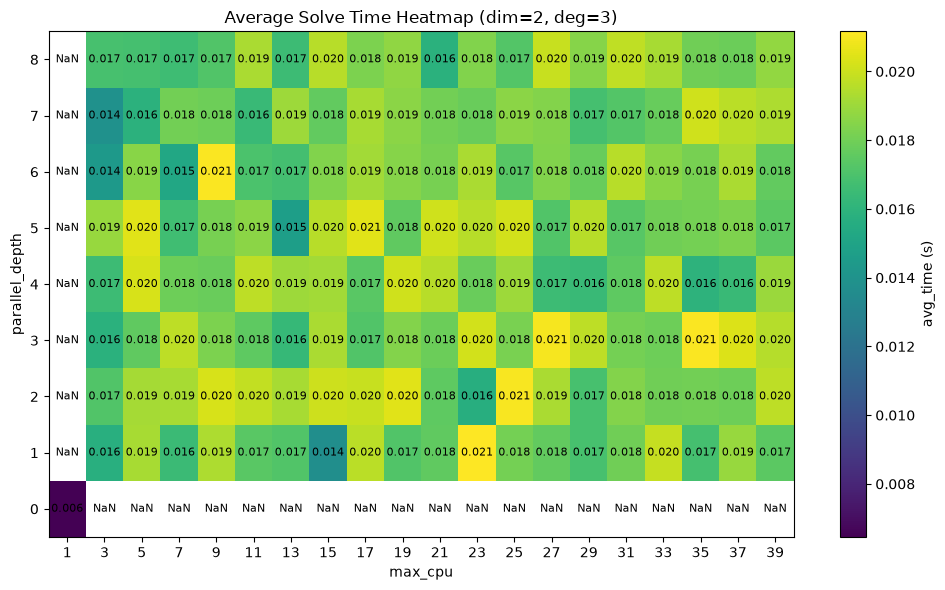

In [30]:
dim = 2
deg = 3
create_heatmap(dim, deg)

If you would like to see how the average solve time changes as degree increase, run the cells below

In [33]:
dim = 2

make_dim_animation(
    df,
    dim_val=dim,
    fps=1,
    annotate=True,
)